Treinando autoencoder para i.i.d...
Treinando autoencoder para Markov...
Ruído sigma=0
Ruído sigma=0.1
Ruído sigma=0.5
Ruído sigma=1.0
Ruído sigma=2.0


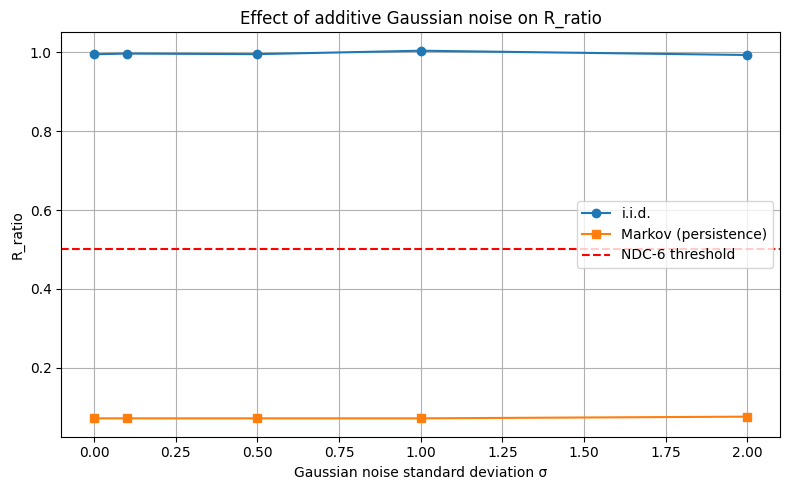

Mistura α=0 (chaos) e 1 (i.i.d.)
Mistura α=0.2 (chaos) e 0.8 (i.i.d.)
Mistura α=0.5 (chaos) e 0.5 (i.i.d.)
Mistura α=0.8 (chaos) e 0.19999999999999996 (i.i.d.)
Mistura α=1.0 (chaos) e 0.0 (i.i.d.)


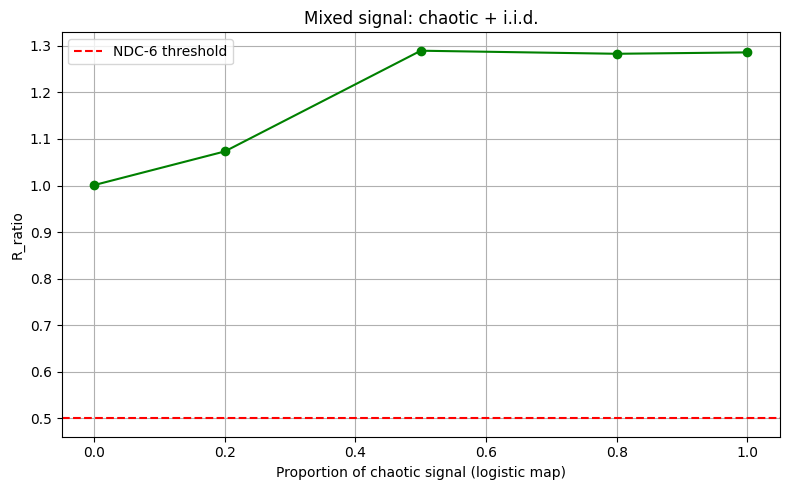

Experimentos concluídos. Arquivos salvos.


In [1]:
# =============================================================================
# Experimento de Robustez do SCD a Ruído Gaussiano e Sinais Mistos
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Configurações
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

N_SAMPLES = 5000
INPUT_DIM = 50
LATENT_DIM = 16
K_CLUSTERS = 4
BATCH_SIZE = 128
EPOCHS = 20

# 1. Gerar dados base: i.i.d. e Markov persistente
X_iid = np.random.rand(N_SAMPLES, INPUT_DIM).astype(np.float32)

K_markov = 4
p_self = 0.95
states = np.zeros(N_SAMPLES, dtype=int)
current = np.random.randint(K_markov)
states[0] = current
for i in range(1, N_SAMPLES):
    if np.random.rand() < p_self:
        current = current
    else:
        new = current
        while new == current:
            new = np.random.randint(K_markov)
        current = new
    states[i] = current
means = np.linspace(-2, 2, K_markov).reshape(-1, 1)
X_markov = np.zeros((N_SAMPLES, INPUT_DIM))
for i, s in enumerate(states):
    X_markov[i] = means[s] + np.random.randn(INPUT_DIM) * 0.5
X_markov = X_markov.astype(np.float32)

# Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

def train_ae(X, epochs=20):
    dataset = TensorDataset(torch.tensor(X))
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    model = Autoencoder(INPUT_DIM, LATENT_DIM)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        loss_total = 0
        for (x,) in loader:
            optimizer.zero_grad()
            recon, _ = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()
            loss_total += loss.item()
    return model

def get_embeddings(model, X):
    model.eval()
    with torch.no_grad():
        _, z = model(torch.tensor(X))
    return z.numpy()

def compute_runs_ratio(labels):
    n = len(labels)
    runs = 1
    for i in range(1, n):
        if labels[i] != labels[i-1]:
            runs += 1
    _, counts = np.unique(labels, return_counts=True)
    R_null = 1 + (n*n - np.sum(counts*counts)) / n
    return runs / R_null

def effrank(Z, eps=0.01):
    _, S, _ = np.linalg.svd(Z, full_matrices=False)
    return np.sum(S > eps * S[0])

def pc1_var(Z):
    return PCA(n_components=1).fit(Z).explained_variance_ratio_[0] * 100

# Treinar modelos base
print("Treinando autoencoder para i.i.d...")
model_iid = train_ae(X_iid, EPOCHS)
Z_iid_clean = get_embeddings(model_iid, X_iid)

print("Treinando autoencoder para Markov...")
model_markov = train_ae(X_markov, EPOCHS)
Z_markov_clean = get_embeddings(model_markov, X_markov)

# =============================================================================
# Experimento 1: Ruído Gaussiano
# =============================================================================
sigma_values = [0, 0.1, 0.5, 1.0, 2.0]
results_iid_noise = []
results_markov_noise = []

for sigma in sigma_values:
    print(f"Ruído sigma={sigma}")
    Z_iid_noisy = Z_iid_clean + np.random.randn(*Z_iid_clean.shape) * sigma
    Z_markov_noisy = Z_markov_clean + np.random.randn(*Z_markov_clean.shape) * sigma

    kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
    labels_iid = kmeans.fit_predict(Z_iid_noisy)
    labels_markov = kmeans.fit_predict(Z_markov_noisy)

    R_iid = compute_runs_ratio(labels_iid)
    R_markov = compute_runs_ratio(labels_markov)
    eff_iid = effrank(Z_iid_noisy)
    eff_markov = effrank(Z_markov_noisy)
    pc1_iid = pc1_var(Z_iid_noisy)
    pc1_markov = pc1_var(Z_markov_noisy)

    results_iid_noise.append([sigma, R_iid, eff_iid, pc1_iid])
    results_markov_noise.append([sigma, R_markov, eff_markov, pc1_markov])

df_iid_noise = pd.DataFrame(results_iid_noise, columns=['sigma', 'R_ratio', 'effrank', 'PC1_var'])
df_markov_noise = pd.DataFrame(results_markov_noise, columns=['sigma', 'R_ratio', 'effrank', 'PC1_var'])

# Figura 1: R_ratio vs sigma
plt.figure(figsize=(8,5))
plt.plot(df_iid_noise['sigma'], df_iid_noise['R_ratio'], 'o-', label='i.i.d.')
plt.plot(df_markov_noise['sigma'], df_markov_noise['R_ratio'], 's-', label='Markov (persistence)')
plt.axhline(0.5, color='red', linestyle='--', label='NDC-6 threshold')
plt.xlabel('Gaussian noise standard deviation σ')
plt.ylabel('R_ratio')
plt.title('Effect of additive Gaussian noise on R_ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('noise_sensitivity_Rratio.png', dpi=150)
plt.savefig('noise_sensitivity_Rratio.tiff', dpi=600, format='tiff', pil_kwargs={'compression': 'tiff_lzw'})
plt.show()

# =============================================================================
# Experimento 2: Sinal misto (caótico + i.i.d.) – opcional
# =============================================================================
# Gerar mapa logístico (caótico)
def logistic_map(r, x0, n):
    x = np.zeros(n)
    x[0] = x0
    for i in range(1, n):
        x[i] = r * x[i-1] * (1 - x[i-1])
    return x

r_chaos = 3.9
x0 = 0.4
N_chaos = N_SAMPLES
chaos = logistic_map(r_chaos, x0, N_chaos).reshape(-1, 1)
chaos = np.tile(chaos, (1, INPUT_DIM))  # replicar para ter INPUT_DIM dimensões

iid = np.random.rand(N_SAMPLES, INPUT_DIM).astype(np.float32)

alphas = [0, 0.2, 0.5, 0.8, 1.0]
results_mixture = []

for alpha in alphas:
    print(f"Mistura α={alpha} (chaos) e {1-alpha} (i.i.d.)")
    X_mix = alpha * chaos + (1-alpha) * iid
    X_mix = X_mix.astype(np.float32)
    model_mix = train_ae(X_mix, EPOCHS)
    Z_mix = get_embeddings(model_mix, X_mix)
    kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=RANDOM_SEED, n_init=10)
    labels = kmeans.fit_predict(Z_mix)
    R_mix = compute_runs_ratio(labels)
    eff_mix = effrank(Z_mix)
    pc1_mix = pc1_var(Z_mix)
    results_mixture.append([alpha, R_mix, eff_mix, pc1_mix])

df_mixture = pd.DataFrame(results_mixture, columns=['alpha_chaos', 'R_ratio', 'effrank', 'PC1_var'])

# Figura 2: R_ratio vs proporção caótica
plt.figure(figsize=(8,5))
plt.plot(df_mixture['alpha_chaos'], df_mixture['R_ratio'], 'o-', color='green')
plt.axhline(0.5, color='red', linestyle='--', label='NDC-6 threshold')
plt.xlabel('Proportion of chaotic signal (logistic map)')
plt.ylabel('R_ratio')
plt.title('Mixed signal: chaotic + i.i.d.')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mixed_signal_Rratio.png', dpi=150)
plt.savefig('mixed_signal_Rratio.tiff', dpi=600, format='tiff', pil_kwargs={'compression': 'tiff_lzw'})
plt.show()

# Salvar dados
df_iid_noise.to_csv('noise_sensitivity_iid.csv', index=False)
df_markov_noise.to_csv('noise_sensitivity_markov.csv', index=False)
df_mixture.to_csv('mixed_signal_results.csv', index=False)

print("Experimentos concluídos. Arquivos salvos.")